<a href="https://colab.research.google.com/github/amrutha-0123/Financial-Sentiment-Analysis-Using-NLP-and-FinBERT/blob/main/Financial-Sentiment-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Sentiment Analysis Using NLP and FinBERT
This notebook performs a comprehensive sentiment analysis on financial news, moving from data cleaning and leakage analysis to classical ML baselines and transformer-based models (BERT & FinBERT).

**Environment & Dataset Setup**


First, we'll install necessary libraries like `transformers` and set up our directory structure. Then, we load the FinancialPhraseBank dataset. This dataset is unique because it provides labels based on the agreement rate of human annotators.

In [3]:
# 1. Environment Setup
!pip install -q sentencepiece tiktoken transformers

import os
import sys
import platform
import torch
import pandas as pd
import numpy as np
import random

# Create required directories
for d in ["data", "models", "reports", "results"]:
    os.makedirs(d, exist_ok=True)

print(f"Python: {platform.python_version()} | PyTorch: {torch.__version__} | GPU: {torch.cuda.is_available()}")

Python: 3.12.13 | PyTorch: 2.11.0+cu128 | GPU: True


In [4]:
# 2. Dataset Loading
# Ensure the zip file is present in the root directory
!unzip -o FinancialPhraseBank-v1.0.zip

Archive:  FinancialPhraseBank-v1.0.zip
   creating: FinancialPhraseBank-v1.0/
  inflating: FinancialPhraseBank-v1.0/License.txt  
   creating: __MACOSX/
   creating: __MACOSX/FinancialPhraseBank-v1.0/
  inflating: __MACOSX/FinancialPhraseBank-v1.0/._License.txt  
  inflating: FinancialPhraseBank-v1.0/README.txt  
  inflating: __MACOSX/FinancialPhraseBank-v1.0/._README.txt  
  inflating: FinancialPhraseBank-v1.0/Sentences_50Agree.txt  
  inflating: FinancialPhraseBank-v1.0/Sentences_66Agree.txt  
  inflating: FinancialPhraseBank-v1.0/Sentences_75Agree.txt  
  inflating: FinancialPhraseBank-v1.0/Sentences_AllAgree.txt  


**Stage 1: Data Cleaning and Deduplication**


Real-world datasets are rarely perfect. Here, we parse the raw text files and consolidate the different annotator agreement levels into a single, clean DataFrame. We also handle duplicates and resolve conflicting labels if identical sentences have different labels from different annotators, we remove them to ensure high-quality ground truth data.

In [5]:
# Stage 1: Data Cleaning and Validation
def read_fpb_file(filepath):
    sentences, labels = [], []
    with open(filepath, 'r', encoding='iso-8859-1') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.rsplit('@', 1)
            if len(parts) == 2:
                sentences.append(parts[0].strip())
                labels.append(parts[1].strip())
    return pd.DataFrame({'sentence': sentences, 'label': labels})

target_files = {"50Agree": "Sentences_50Agree.txt", "66Agree": "Sentences_66Agree.txt", "75Agree": "Sentences_75Agree.txt", "AllAgree": "Sentences_AllAgree.txt"}
raw_dfs = {k: read_fpb_file(next(os.path.join(r, f) for r, _, fs in os.walk('.') for f in fs if f == path)) for k, path in target_files.items()}

# Deduplication & Conflict Resolution (Strictly following original logic)
df_50 = raw_dfs["50Agree"].copy()
dup_groups = df_50.groupby('sentence')['label'].agg(['count', 'nunique']).reset_index()
conflicting_sentences = set(dup_groups[dup_groups['nunique'] > 1]['sentence'])

df_cleaned = df_50[~df_50['sentence'].isin(conflicting_sentences)].copy()
df_cleaned = df_cleaned.drop_duplicates(subset=['sentence'], keep='first').reset_index(drop=True)

# Agreement level metadata
set_all, set_75, set_66 = set(raw_dfs["AllAgree"]['sentence']), set(raw_dfs["75Agree"]['sentence']), set(raw_dfs["66Agree"]['sentence'])
def get_level(s):
    if s in set_all: return "AllAgree"
    if s in set_75: return "75Agree"
    if s in set_66: return "66Agree"
    return "50_only"

df_cleaned['agreement_level'] = df_cleaned['sentence'].apply(get_level)
df_cleaned.to_csv("data/cleaned_phrasebank_50agree.csv", index=False)

print(f"Stage 1 Complete. Cleaned Rows: {len(df_cleaned)}")
assert len(df_cleaned) == 4836

Stage 1 Complete. Cleaned Rows: 4836


**Stage 2: Addressing Data Leakage via Template Normalization**

Financial news often uses boilerplates or "templates" (e.g., "Operating profit rose to EUR X mn from EUR Y mn in QZ"). If two variations of the same template end up in both our training and validation sets, our model might memorize the template structure rather than learning true sentiment, leading to data leakage and potentially affecting measured performance.

To control for this, we employ a method to identify and group these template variations together before splitting our dataset.

### Step 2.1: Template Normalization & Leakage Identification

To detect these boilerplate structures, we use Regular Expressions (Regex) to mask out variable entities like numbers, dates, and currencies, replacing them with generic tags (`<NUM>`, `<DATE>`, `<CURR>`).

Sentences that become perfectly identical after this masking process are considered variations of the exact same template. We then group these identical templates together and assign them a unique `group_id`.

In [6]:
import re

def normalize_template(text):
    t = text.lower()

    # Currency amounts: symbol/code before the number  (e.g. "eur 3.11", "$5", "£2.5")
    t = re.sub(r'(\$|eur|usd|gbp|€|£)\s*\d+(\.\d+)?', '<CURR>', t)

    # Currency amounts: number before the code/word     (e.g. "3.11 eur", "5 dollars")
    t = re.sub(r'\d+(\.\d+)?\s*(eur|usd|gbp|dollars|euros)', '<CURR>', t)

    # Percentages
    t = re.sub(r'\d+(\.\d+)?\s*(%|percent|per cent)', '<PCT>', t)

    # Years
    t = re.sub(r'\b(19|20)\d{2}\b', '<DATE>', t)

    # Quarters (Q1–Q4)
    t = re.sub(r'\bq[1-4]\b', '<DATE>', t)

    # "<day> <month>" dates
    t = re.sub(
        r'\b\d{1,2}\s+(january|february|march|april|may|june|july|august|september|october|november|december)\b',
        '<DATE>', t
    )

    # Catch-all: any remaining bare numbers (run LAST)
    t = re.sub(r'\b\d+([\.,]\d+)*\b', '<NUM>', t)

    return re.sub(r'\s+', ' ', t).strip()

# ---- this part was missing: actually build and save the grouped dataset ----
df = pd.read_csv("data/cleaned_phrasebank_50agree.csv")
df['normalized_template'] = df['sentence'].apply(normalize_template)
template_counts = df.groupby('normalized_template').size().reset_index(name='count')
template_to_id = {tmpl: idx for idx, tmpl in enumerate(template_counts['normalized_template'])}
df['group_id'] = df['normalized_template'].map(template_to_id)

df.to_csv("data/phrasebank_with_groups.csv", index=False)
print(f"Stage 2 Complete. Unique Templates: {len(template_counts)}")

Stage 2 Complete. Unique Templates: 4805


### Step 2.2: Methodological Review & Template Extraction

Before we move on to data splitting, we must validate that our normalization logic worked as intended.

The cell below extracts and prints all the multi-member template groups so we can visually inspect the masked sentences. It also compares our advanced normalization strategy against a simpler baseline (which only masks digits) to demonstrate that our nuanced approach successfully identifies more subtle template groups.

In [8]:
import pandas as pd
import re

print("="*80)
print("STAGE 2: METHODOLOGICAL REVIEW & TEMPLATE EXTRACTION")
print("="*80)

# Load the dataset from Stage 2
df = pd.read_csv("data/phrasebank_with_groups.csv")

# ==========================================
# 1. REPORT ALL 24 MULTI-MEMBER GROUPS
# ==========================================
print("\n--- 1. ALL 24 MULTI-MEMBER TEMPLATE GROUPS ---")
template_counts = df.groupby('normalized_template').agg(
    group_id=('group_id', 'first'),
    group_size=('sentence', 'count'),
    labels=('label', list),
    agreements=('agreement_level', list),
    sentences=('sentence', list)
).reset_index()

multi_groups = template_counts[template_counts['group_size'] > 1].sort_values(by='group_size', ascending=False)

for i, row in multi_groups.iterrows():
    print(f"\nGroup ID: {row['group_id']} | Size: {row['group_size']}")
    print(f"Template: {row['normalized_template']}")
    for s, l, a in zip(row['sentences'], row['labels'], row['agreements']):
        print(f"  [{l.upper():8s}] [{a:8s}] {s}")

# ==========================================
# 4. COMPARE WITH SIMPLER NORMALIZATION
# ==========================================
def simple_normalize(text):
    """Simple baseline: Lowercase, replace digits with <NUM>, collapse whitespace"""
    t = text.lower()
    t = re.sub(r'\d+', '<NUM>', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['simple_template'] = df['sentence'].apply(simple_normalize)
simple_counts = df.groupby('simple_template').size()
simple_multi = simple_counts[simple_counts > 1]

print("\n" + "="*80)
print("--- 4. NORMALIZATION STRATEGY COMPARISON ---")
print("="*80)

print("CURRENT NORMALIZATION (<NUM>, <PCT>, <CURR>, <DATE>):")
print(f" - Unique Templates: {len(template_counts)}")
print(f" - Multi-member groups: {len(multi_groups)}")
print(f" - Sentences in multi groups: {multi_groups['group_size'].sum()}")

print("\nSIMPLER NORMALIZATION (Lowercase + digits to <NUM> only):")
print(f" - Unique Templates: {len(simple_counts)}")
print(f" - Multi-member groups: {len(simple_multi)}")
print(f" - Sentences in multi groups: {simple_multi.sum()}")

print("\n(Script complete. Awaiting AI review.)")

STAGE 2: METHODOLOGICAL REVIEW & TEMPLATE EXTRACTION

--- 1. ALL 24 MULTI-MEMBER TEMPLATE GROUPS ---

Group ID: 2569 | Size: 6
Template: operating profit rose to <CURR> mn from <CURR> mn in the corresponding period in <DATE> .
  [POSITIVE] [AllAgree] Operating profit rose to EUR 3.11 mn from EUR 1.22 mn in the corresponding period in 2009 .
  [POSITIVE] [AllAgree] Operating profit rose to EUR 1.6 mn from EUR 1.1 mn in the corresponding period in 2006 .
  [POSITIVE] [AllAgree] Operating profit rose to EUR 13.5 mn from EUR 9.7 mn in the corresponding period in 2006 .
  [POSITIVE] [AllAgree] Operating profit rose to EUR 26.7 mn from EUR 14.9 mn in the corresponding period in 2006 .
  [POSITIVE] [AllAgree] Operating profit rose to EUR 3.2 mn from EUR 1.0 mn in the corresponding period in 2008 .
  [POSITIVE] [AllAgree] Operating profit rose to EUR 9.2 mn from EUR 6.8 mn in the corresponding period in 2007 .

Group ID: 823 | Size: 3
Template: both operating profit and net sales for the six-m

**Stage 3: Leakage-Controlled Data Splitting**


To demonstrate the impact of controlling for template-level overlap, we will create two distinct train/validation/test splits:

**1. Standard Random Split**: A conventional stratified random split that does not explicitly control for template-level overlap.

**2. Template-Grouped (Leakage-Controlled) Split:** A grouped split based on normalized template IDs that keeps samples belonging to the same identified template group within the same partition, thus controlling for identified template-level overlap.

In [9]:
# Stage 3: Fixed Split Generation
from sklearn.model_selection import train_test_split, GroupShuffleSplit

df = pd.read_csv("data/phrasebank_with_groups.csv")
SEED = 42

# 1. Standard Split
tr_idx, temp_idx = train_test_split(df.index, test_size=0.3, stratify=df['label'], random_state=SEED)
val_idx, ts_idx = train_test_split(temp_idx, test_size=0.5, stratify=df.loc[temp_idx, 'label'], random_state=SEED)
df['split_standard'] = 'train'
df.loc[val_idx, 'split_standard'] = 'val'
df.loc[ts_idx, 'split_standard'] = 'test'

# 2. Grouped Split (Leakage-Controlled)
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
tr_g_loc, temp_g_loc = next(gss.split(df, groups=df['group_id']))
tr_g_idx, temp_g_idx = df.index[tr_g_loc], df.index[temp_g_loc]

gss_v = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
tmp_df = df.loc[temp_g_idx]
val_g_loc, ts_g_loc = next(gss_v.split(tmp_df, groups=tmp_df['group_id']))

df['split_grouped'] = 'train'
df.loc[temp_g_idx[val_g_loc], 'split_grouped'] = 'val'
df.loc[temp_g_idx[ts_g_loc], 'split_grouped'] = 'test'

# Save Artifacts
df.to_csv("data/split_assignments.csv", index=False)
df.drop(columns=['split_grouped']).to_csv("data/standard_split.csv", index=False)
df.drop(columns=['split_standard']).to_csv("data/grouped_split.csv", index=False)

print("Standard Split:", df['split_standard'].value_counts().to_dict())
print("Grouped Split:", df['split_grouped'].value_counts().to_dict())

Standard Split: {'train': 3385, 'test': 726, 'val': 725}
Grouped Split: {'train': 3383, 'test': 731, 'val': 722}


**Stage 4: Exploratory Data Analysis (EDA)**


Before modeling, we need to understand our training data. We will analyze the distribution of sentence lengths (which is crucial for setting the `MAX_LEN` in our BERT models) and check if human annotator disagreement correlates with sentence complexity. We'll also extract the most frequent words for positive and negative classes to see if simple keywords are enough to drive sentiment.

STAGE 4: EXPLORATORY DATA ANALYSIS (TRAINING SET ONLY)
Analyzing Training Set: 3385 rows

--- WORD COUNT STATISTICS ---
count    3385.0
mean       23.1
std        10.0
min         2.0
50%        21.0
90%        37.0
95%        42.0
99%        50.0
max        81.0
Name: word_count, dtype: float64

--- MEDIAN WORD COUNT BY AGREEMENT LEVEL ---
agreement_level
AllAgree    21.0
75Agree     22.0
66Agree     23.0
50_only     22.0
Name: word_count, dtype: float64


/tmp/ipykernel_651/3897023672.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='label', y='word_count', palette=colors, ax=axes[0], order=['negative', 'neutral', 'positive'])


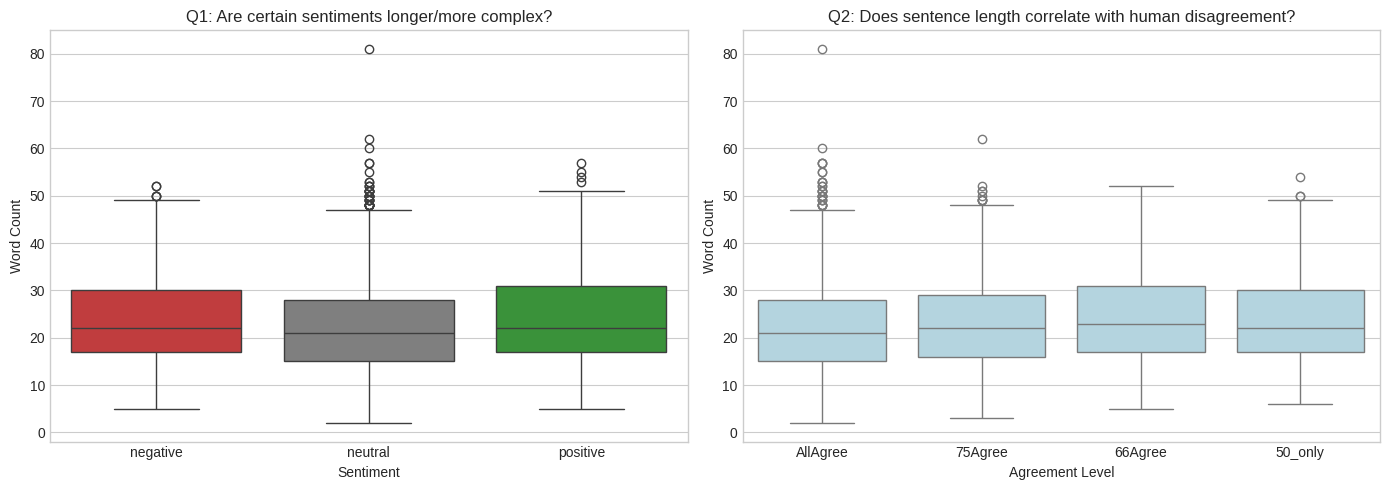


--- TOP 10 WORDS BY CLASS (Excluding English Stopwords) ---
POSITIVE: ['eur', 'company', 'mn', 'said', 'net', 'year', 'sales', 'profit', 'finnish', 'million']
NEGATIVE: ['eur', 'mn', 'profit', 'net', 'year', 'operating', 'sales', 'company', 'period', 'finnish']

--- EXAMPLES: HIGH VS LOW AGREEMENT ---

[Unanimous Agreement (AllAgree) - Clear Signal]
 - [NEUTRAL] The markets expect Heineken to sell Hartwall as a whole or in parts .
 - [NEUTRAL] Basware finances the acquisition with a bank loan .

[Low Agreement (50_only) - Ambiguous Signal]
 - [NEUTRAL] The impact of this acquisition to Teleste 's net sales for 2010 is estimated to be approximately EUR 2 million .
 - [POSITIVE] Israeli cable network operator HOT Telecom has chosen Teleste , an international technology group , as its exclusive provider of FTTx equipment in Israel , according to Teleste today .

STAGE 4 COMPLETED. Plots saved to reports/


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Formatting for plots
plt.style.use('seaborn-v0_8-whitegrid')
colors = {'positive': '#2ca02c', 'neutral': '#7f7f7f', 'negative': '#d62728'}

print("="*80)
print("STAGE 4: EXPLORATORY DATA ANALYSIS (TRAINING SET ONLY)")
print("="*80)

# Load standard split and isolate TRAIN set
df = pd.read_csv("data/standard_split.csv")
df_train = df[df['split_standard'] == 'train'].copy()

print(f"Analyzing Training Set: {len(df_train)} rows\n")

# ==========================================
# 1. SEQUENCE LENGTH ANALYSIS
# ==========================================
df_train['word_count'] = df_train['sentence'].apply(lambda x: len(str(x).split()))
df_train['char_count'] = df_train['sentence'].apply(lambda x: len(str(x)))

print("--- WORD COUNT STATISTICS ---")
print(df_train['word_count'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Word Count Distribution by Class
sns.boxplot(data=df_train, x='label', y='word_count', palette=colors, ax=axes[0], order=['negative', 'neutral', 'positive'])
axes[0].set_title('Q1: Are certain sentiments longer/more complex?')
axes[0].set_ylabel('Word Count')
axes[0].set_xlabel('Sentiment')

# ==========================================
# 2. AGREEMENT LEVEL ANALYSIS
# ==========================================
print("\n--- MEDIAN WORD COUNT BY AGREEMENT LEVEL ---")
agreements = ["AllAgree", "75Agree", "66Agree", "50_only"]
print(df_train.groupby('agreement_level')['word_count'].median().reindex(agreements))

# Plot 2: Word Count by Agreement
sns.boxplot(data=df_train, x='agreement_level', y='word_count', ax=axes[1], order=agreements, color='lightblue')
axes[1].set_title('Q2: Does sentence length correlate with human disagreement?')
axes[1].set_ylabel('Word Count')
axes[1].set_xlabel('Agreement Level')

plt.tight_layout()
plt.savefig("reports/eda_length_analysis.png")
plt.show()

# ==========================================
# 3. FREQUENT TERMS BY CLASS
# ==========================================
print("\n--- TOP 10 WORDS BY CLASS (Excluding English Stopwords) ---")
def get_top_n_words(corpus, n=10):
    vec = CountVectorizer(stop_words='english', max_features=1000).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

for label in ['positive', 'negative']:
    corpus = df_train[df_train['label'] == label]['sentence']
    top_words = get_top_n_words(corpus, 10)
    print(f"{label.upper()}: {[w[0] for w in top_words]}")

# ==========================================
# 4. QUALITATIVE AGREEMENT EXAMPLES
# ==========================================
print("\n--- EXAMPLES: HIGH VS LOW AGREEMENT ---")
print("\n[Unanimous Agreement (AllAgree) - Clear Signal]")
all_agree_samples = df_train[df_train['agreement_level'] == 'AllAgree'].sample(2, random_state=42)
for _, row in all_agree_samples.iterrows():
    print(f" - [{row['label'].upper()}] {row['sentence']}")

print("\n[Low Agreement (50_only) - Ambiguous Signal]")
low_agree_samples = df_train[df_train['agreement_level'] == '50_only'].sample(2, random_state=42)
for _, row in low_agree_samples.iterrows():
    print(f" - [{row['label'].upper()}] {row['sentence']}")

print("\n" + "="*80)
print("STAGE 4 COMPLETED. Plots saved to reports/")
print("="*80)

**Stages 5 & 6: Classical Machine Learning Baselines**


Before deploying computationally expensive Transformer models, we must establish a strong baseline. We use TF-IDF vectorization paired with traditional algorithms: Logistic Regression, Naive Bayes, and Support Vector Machines (Linear SVC).



In [11]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, accuracy_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

print("="*80)
print("STAGE 5: CLASSICAL ML BASELINES (VALIDATION SETS ONLY)")
print("="*80)

# 1. LOAD DATASETS
df_std = pd.read_csv("data/standard_split.csv")
df_grp = pd.read_csv("data/grouped_split.csv")

# Standard Split Data (Train and Validation ONLY)
X_train_std = df_std[df_std['split_standard'] == 'train']['sentence']
y_train_std = df_std[df_std['split_standard'] == 'train']['label']
X_val_std = df_std[df_std['split_standard'] == 'val']['sentence']
y_val_std = df_std[df_std['split_standard'] == 'val']['label']

# Grouped Split Data (Train and Validation ONLY)
X_train_grp = df_grp[df_grp['split_grouped'] == 'train']['sentence']
y_train_grp = df_grp[df_grp['split_grouped'] == 'train']['label']
X_val_grp = df_grp[df_grp['split_grouped'] == 'val']['sentence']
y_val_grp = df_grp[df_grp['split_grouped'] == 'val']['label']

# 2. TF-IDF VECTORIZATION
# Identical preprocessing for both splits to isolate the effect of leakage control
vectorizer_std = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_std_vec = vectorizer_std.fit_transform(X_train_std)
X_val_std_vec = vectorizer_std.transform(X_val_std)

vectorizer_grp = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_grp_vec = vectorizer_grp.fit_transform(X_train_grp)
X_val_grp_vec = vectorizer_grp.transform(X_val_grp)

# 3. DEFINE MODELS (No class weighting)
models = {
    "Majority Class": DummyClassifier(strategy='most_frequent'),
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42, dual=False)
}

# 4. EVALUATION LOOP ON VALIDATION SETS
results = []

def evaluate_model(name, model, X_train, y_train, X_val, y_val, split_name):
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    macro_f1 = f1_score(y_val, preds, average='macro')
    acc = accuracy_score(y_val, preds)
    return {"Model": name, "Split": split_name, "Macro-F1": macro_f1, "Accuracy": acc}

for name, model in models.items():
    # Evaluate on Standard Validation
    res_std = evaluate_model(name, model, X_train_std_vec, y_train_std, X_val_std_vec, y_val_std, "Standard_Val")
    results.append(res_std)

    # Evaluate on Grouped Validation
    res_grp = evaluate_model(name, model, X_train_grp_vec, y_train_grp, X_val_grp_vec, y_val_grp, "Grouped_Val")
    results.append(res_grp)

# 5. DISPLAY RESULTS
results_df = pd.DataFrame(results)

print("\n--- BASELINE PERFORMANCE SUMMARY (VALIDATION SETS) ---")
pivot_df = results_df.pivot(index="Model", columns="Split", values=["Macro-F1", "Accuracy"]).round(4)
# Reorder columns for side-by-side comparison
pivot_df = pivot_df[[
    ("Macro-F1", "Standard_Val"), ("Macro-F1", "Grouped_Val"),
    ("Accuracy", "Standard_Val"), ("Accuracy", "Grouped_Val")
]]
print(pivot_df)

# 6. DETAILED SVM REPORT
# Retraining SVMs explicitly to print full classification reports
print("\n--- DETAILED SVM REPORT: STANDARD VALIDATION ---")
svm_std = models["Linear SVM"]
svm_std.fit(X_train_std_vec, y_train_std)
preds_std = svm_std.predict(X_val_std_vec)
print(classification_report(y_val_std, preds_std, digits=3))

print("\n--- DETAILED SVM REPORT: GROUPED VALIDATION ---")
svm_grp = models["Linear SVM"]
svm_grp.fit(X_train_grp_vec, y_train_grp)
preds_grp = svm_grp.predict(X_val_grp_vec)
print(classification_report(y_val_grp, preds_grp, digits=3))

print("\n" + "="*80)
print("STAGE 5 COMPLETED.")
print("="*80)

STAGE 5: CLASSICAL ML BASELINES (VALIDATION SETS ONLY)

--- BASELINE PERFORMANCE SUMMARY (VALIDATION SETS) ---
                        Macro-F1                 Accuracy            
Split               Standard_Val Grouped_Val Standard_Val Grouped_Val
Model                                                                
Linear SVM                0.6558      0.6115       0.7310      0.7050
Logistic Regression       0.5941      0.5991       0.7214      0.7161
Majority Class            0.2486      0.2452       0.5945      0.5817
Naive Bayes               0.4862      0.5138       0.6814      0.6814

--- DETAILED SVM REPORT: STANDARD VALIDATION ---
              precision    recall  f1-score   support

    negative      0.638     0.489     0.553        90
     neutral      0.782     0.863     0.820       431
    positive      0.633     0.559     0.594       204

    accuracy                          0.731       725
   macro avg      0.684     0.637     0.656       725
weighted avg      0.722

In Stage 6, we introduce class weighting (`class_weight='balanced'`) to help the models penalize mistakes on the minority classes (Positive/Negative) more heavily, as the dataset is predominantly "Neutral". We evaluate both the Standard Random Split and Template-Grouped Split to observe how controlling for identified template-level overlap affects traditional ML.

In [12]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, accuracy_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

print("="*80)
print("STAGE 6: CLASS-WEIGHTED BASELINES (VALIDATION SETS ONLY)")
print("="*80)

# 1. LOAD DATASETS (Strictly Train & Val)
df_std = pd.read_csv("data/standard_split.csv")
df_grp = pd.read_csv("data/grouped_split.csv")

X_train_std = df_std[df_std['split_standard'] == 'train']['sentence']
y_train_std = df_std[df_std['split_standard'] == 'train']['label']
X_val_std = df_std[df_std['split_standard'] == 'val']['sentence']
y_val_std = df_std[df_std['split_standard'] == 'val']['label']

X_train_grp = df_grp[df_grp['split_grouped'] == 'train']['sentence']
y_train_grp = df_grp[df_grp['split_grouped'] == 'train']['label']
X_val_grp = df_grp[df_grp['split_grouped'] == 'val']['sentence']
y_val_grp = df_grp[df_grp['split_grouped'] == 'val']['label']

# 2. IDENTICAL TF-IDF VECTORIZATION
vectorizer_std = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_std_vec = vectorizer_std.fit_transform(X_train_std)
X_val_std_vec = vectorizer_std.transform(X_val_std)

vectorizer_grp = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_grp_vec = vectorizer_grp.fit_transform(X_train_grp)
X_val_grp_vec = vectorizer_grp.transform(X_val_grp)

# 3. DEFINE CLASS-WEIGHTED MODELS
models = {
    "Logistic Regression (Weighted)": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Linear SVM (Weighted)": LinearSVC(class_weight='balanced', random_state=42, dual=False)
}

# 4. EVALUATION LOOP
results = []

def evaluate_model(name, model, X_train, y_train, X_val, y_val, split_name):
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    macro_f1 = f1_score(y_val, preds, average='macro')
    acc = accuracy_score(y_val, preds)
    return {"Model": name, "Split": split_name, "Macro-F1": macro_f1, "Accuracy": acc}

for name, model in models.items():
    res_std = evaluate_model(name, model, X_train_std_vec, y_train_std, X_val_std_vec, y_val_std, "Standard_Val")
    res_grp = evaluate_model(name, model, X_train_grp_vec, y_train_grp, X_val_grp_vec, y_val_grp, "Grouped_Val")
    results.extend([res_std, res_grp])

# 5. DISPLAY MACRO-F1 & ACCURACY
results_df = pd.DataFrame(results)
print("\n--- WEIGHTED BASELINE PERFORMANCE SUMMARY ---")
pivot_df = results_df.pivot(index="Model", columns="Split", values=["Macro-F1", "Accuracy"]).round(4)
pivot_df = pivot_df[[
    ("Macro-F1", "Standard_Val"), ("Macro-F1", "Grouped_Val"),
    ("Accuracy", "Standard_Val"), ("Accuracy", "Grouped_Val")
]]
print(pivot_df)

# 6. DETAILED SVM REPORTS (To analyze Precision vs Recall trade-off)
print("\n--- DETAILED WEIGHTED SVM REPORT: STANDARD VALIDATION ---")
svm_std = models["Linear SVM (Weighted)"]
svm_std.fit(X_train_std_vec, y_train_std)
print(classification_report(y_val_std, svm_std.predict(X_val_std_vec), digits=3))

print("\n--- DETAILED WEIGHTED SVM REPORT: GROUPED VALIDATION ---")
svm_grp = models["Linear SVM (Weighted)"]
svm_grp.fit(X_train_grp_vec, y_train_grp)
print(classification_report(y_val_grp, svm_grp.predict(X_val_grp_vec), digits=3))

print("\n" + "="*80)
print("STAGE 6 COMPLETED.")
print("="*80)

STAGE 6: CLASS-WEIGHTED BASELINES (VALIDATION SETS ONLY)

--- WEIGHTED BASELINE PERFORMANCE SUMMARY ---
                                   Macro-F1                 Accuracy  \
Split                          Standard_Val Grouped_Val Standard_Val   
Model                                                                  
Linear SVM (Weighted)                0.6593      0.6492       0.7214   
Logistic Regression (Weighted)       0.6581      0.6481       0.7131   

                                            
Split                          Grouped_Val  
Model                                       
Linear SVM (Weighted)               0.7133  
Logistic Regression (Weighted)      0.7064  

--- DETAILED WEIGHTED SVM REPORT: STANDARD VALIDATION ---
              precision    recall  f1-score   support

    negative      0.595     0.556     0.575        90
     neutral      0.796     0.821     0.808       431
    positive      0.607     0.583     0.595       204

    accuracy                     

In [13]:
import os
import sys
import json
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_recall_fscore_support

# Ensure transformers is installed
try:
    import transformers
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup, set_seed
except ImportError:
    print("Installing transformers library...")
    os.system("pip install -q transformers")
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup, set_seed

print("="*80)
print("STAGE 7: GENERAL TRANSFORMER BASELINE (bert-base-uncased)")
print("="*80)

# ==========================================
# 0. SETUP DIRECTORIES & GPU VERIFICATION
# ==========================================
os.makedirs("results/stage7", exist_ok=True)
os.makedirs("reports/stage7", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Execution Device: {device}")
if device.type != "cuda":
    raise RuntimeError("GPU is not enabled! Please switch Colab runtime to GPU before continuing.")

# Set deterministic seed
SEED = 42
def set_deterministic_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

set_deterministic_seed(SEED)

# ==========================================
# 1. PRE-TRAINING DATASET VERIFICATION
# ==========================================
print("\n--- 1. VERIFYING STAGE 3 ARTIFACTS ---")

std_path = "data/standard_split.csv"
grp_path = "data/grouped_split.csv"

assert os.path.exists(std_path), f"Missing artifact: {std_path}"
assert os.path.exists(grp_path), f"Missing artifact: {grp_path}"

df_std = pd.read_csv(std_path)
df_grp = pd.read_csv(grp_path)

# Verify required columns
req_cols = ["sentence", "label", "agreement_level", "group_id"]
for col in req_cols:
    assert col in df_std.columns, f"Missing column {col} in {std_path}"
    assert col in df_grp.columns, f"Missing column {col} in {grp_path}"

# Row count checks
std_train_len = len(df_std[df_std['split_standard'] == 'train'])
std_val_len   = len(df_std[df_std['split_standard'] == 'val'])
std_test_len  = len(df_std[df_std['split_standard'] == 'test'])

grp_train_len = len(df_grp[df_grp['split_grouped'] == 'train'])
grp_val_len   = len(df_grp[df_grp['split_grouped'] == 'val'])
grp_test_len  = len(df_grp[df_grp['split_grouped'] == 'test'])

print(f"Standard Split Counts -> Train: {std_train_len} | Val: {std_val_len} | Test: {std_test_len}")
print(f"Grouped Split Counts  -> Train: {grp_train_len} | Val: {grp_val_len} | Test: {grp_test_len}")

# Assert exact sizes
assert std_train_len == 3385, f"Expected 3385 standard train rows, got {std_train_len}"
assert std_val_len   == 725,  f"Expected 725 standard val rows, got {std_val_len}"
assert std_test_len  == 726,  f"Expected 726 standard test rows, got {std_test_len}"

assert grp_train_len == 3383, f"Expected 3383 grouped train rows, got {grp_train_len}"
assert grp_val_len   == 722,  f"Expected 722 grouped val rows, got {grp_val_len}"
assert grp_test_len  == 731,  f"Expected 731 grouped test rows, got {grp_test_len}"

# Verify class labels
valid_labels = {'negative', 'neutral', 'positive'}
assert set(df_std['label'].unique()) == valid_labels, f"Invalid labels in Standard: {set(df_std['label'].unique())}"
assert set(df_grp['label'].unique()) == valid_labels, f"Invalid labels in Grouped: {set(df_grp['label'].unique())}"

print("[VERIFICATION PASSED] All Stage 3 dataset dimensions and columns verified successfully.")

# ==========================================
# 2. MODEL & DATASET DEFINITION
# ==========================================
MODEL_NAME = "bert-base-uncased"
MAX_LEN = 64
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 3

label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}
class_names = ['negative', 'neutral', 'positive']

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class PyTorchFPBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = list(texts)
        self.labels = [label2id[l] for l in labels]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def train_one_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

def run_experiment(split_name, train_df, val_df):
    print(f"\n" + "="*60)
    print(f"RUNNING BERT BASELINE EXPERIMENT: {split_name.upper()} SPLIT")
    print("="*60)

    set_deterministic_seed(SEED)

    train_dataset = PyTorchFPBDataset(train_df['sentence'], train_df['label'], tokenizer, max_len=MAX_LEN)
    val_dataset   = PyTorchFPBDataset(val_df['sentence'], val_df['label'], tokenizer, max_len=MAX_LEN)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        id2label=id2label,
        label2id=label2id
    ).to(device)

    total_steps = len(train_loader) * EPOCHS
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )

    history = []
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device)
        preds, labels, _ = evaluate_model(model, val_loader, device)
        val_macro_f1 = f1_score(labels, preds, average='macro')
        val_acc = accuracy_score(labels, preds)
        print(f"Epoch {epoch}/{EPOCHS} - Train Loss: {train_loss:.4f} | Val Macro-F1: {val_macro_f1:.4f} | Val Acc: {val_acc:.4f}")
        history.append({'epoch': epoch, 'train_loss': train_loss, 'val_macro_f1': val_macro_f1, 'val_acc': val_acc})

    # Final Evaluation on Validation
    final_preds, final_labels, final_probs = evaluate_model(model, val_loader, device)

    macro_f1 = f1_score(final_labels, final_preds, average='macro')
    acc = accuracy_score(final_labels, final_preds)
    p_prec, p_rec, p_f1, _ = precision_recall_fscore_support(final_labels, final_preds, average=None, labels=[0, 1, 2])

    cm = confusion_matrix(final_labels, final_preds)
    report_text = classification_report(final_labels, final_preds, target_names=class_names, digits=4)
    report_dict = classification_report(final_labels, final_preds, target_names=class_names, output_dict=True)

    # Save Predictions DataFrame
    val_results_df = val_df[['sentence', 'label', 'agreement_level', 'group_id']].copy()
    val_results_df['pred_label'] = [id2label[p] for p in final_preds]
    val_results_df['prob_negative'] = final_probs[:, 0]
    val_results_df['prob_neutral']  = final_probs[:, 1]
    val_results_df['prob_positive'] = final_probs[:, 2]

    pred_save_path = f"results/stage7/stage7_bert_{split_name.lower()}_val_preds.csv"
    val_results_df.to_csv(pred_save_path, index=False)

    # Save Metrics & Reports
    metrics_summary = {
        'model': MODEL_NAME,
        'split': split_name,
        'macro_f1': float(macro_f1),
        'accuracy': float(acc),
        'negative_precision': float(p_prec[0]),
        'negative_recall': float(p_rec[0]),
        'negative_f1': float(p_f1[0]),
        'neutral_f1': float(p_f1[1]),
        'positive_f1': float(p_f1[2]),
        'confusion_matrix': cm.tolist(),
        'training_history': history
    }

    json_save_path = f"results/stage7/stage7_bert_{split_name.lower()}_metrics.json"
    with open(json_save_path, "w") as f:
        json.dump(metrics_summary, f, indent=2)

    txt_report_path = f"reports/stage7/stage7_bert_{split_name.lower()}_classification_report.txt"
    with open(txt_report_path, "w") as f:
        f.write(f"MODEL: {MODEL_NAME} | SPLIT: {split_name}\n")
        f.write("="*60 + "\n")
        f.write(report_text)

    return metrics_summary, report_text

# ==========================================
# 3. EXECUTE EXPERIMENTS
# ==========================================
# Exclude test sets explicitly
train_std_df = df_std[df_std['split_standard'] == 'train'].reset_index(drop=True)
val_std_df   = df_std[df_std['split_standard'] == 'val'].reset_index(drop=True)

train_grp_df = df_grp[df_grp['split_grouped'] == 'train'].reset_index(drop=True)
val_grp_df   = df_grp[df_grp['split_grouped'] == 'val'].reset_index(drop=True)

metrics_std, report_std = run_experiment("Standard", train_std_df, val_std_df)
metrics_grp, report_grp = run_experiment("Grouped", train_grp_df, val_grp_df)

# ==========================================
# 4. FINAL COMPARISON & REPORT
# ==========================================
print("\n" + "="*80)
print("STAGE 7 SUMMARY & COMPARISON WITH CLASSICAL BASELINE")
print("="*80)

summary_table = pd.DataFrame([
    {
        "Model": "Weighted LogReg (Stage 6)",
        "Standard Val Macro-F1": 0.6535,
        "Grouped Val Macro-F1": 0.6649,
        "Grouped Neg Recall": 0.5310, # Stage 6 Weighted LogReg
        "Grouped Neg F1": 0.5800
    },
    {
        "Model": "Linear SVM Weighted (Stage 6)",
        "Standard Val Macro-F1": 0.6553,
        "Grouped Val Macro-F1": 0.6428,
        "Grouped Neg Recall": 0.5208,
        "Grouped Neg F1": 0.5618
    },
    {
        "Model": f"BERT Base Uncased (Stage 7)",
        "Standard Val Macro-F1": round(metrics_std['macro_f1'], 4),
        "Grouped Val Macro-F1": round(metrics_grp['macro_f1'], 4),
        "Grouped Neg Recall": round(metrics_grp['negative_recall'], 4),
        "Grouped Neg F1": round(metrics_grp['negative_f1'], 4)
    }
])

print("\n--- PERFORMANCE SUMMARY TABLE ---")
print(summary_table.to_string(index=False))

print("\n--- DETAILED BERT REPORT: STANDARD VALIDATION ---")
print(report_std)

print("\n--- DETAILED BERT REPORT: GROUPED VALIDATION ---")
print(report_grp)

print("\n" + "="*80)
print("STAGE 7 COMPLETED. Artifacts saved in results/stage7 and reports/stage7.")
print("="*80)

STAGE 7: GENERAL TRANSFORMER BASELINE (bert-base-uncased)
Execution Device: cuda

--- 1. VERIFYING STAGE 3 ARTIFACTS ---
Standard Split Counts -> Train: 3385 | Val: 725 | Test: 726
Grouped Split Counts  -> Train: 3383 | Val: 722 | Test: 731
[VERIFICATION PASSED] All Stage 3 dataset dimensions and columns verified successfully.


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 - Train Loss: 0.6914 | Val Macro-F1: 0.8061 | Val Acc: 0.8290
Epoch 2/3 - Train Loss: 0.3207 | Val Macro-F1: 0.8397 | Val Acc: 0.8524
Epoch 3/3 - Train Loss: 0.1775 | Val Macro-F1: 0.8439 | Val Acc: 0.8607

RUNNING BERT BASELINE EXPERIMENT: GROUPED SPLIT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 - Train Loss: 0.6892 | Val Macro-F1: 0.8118 | Val Acc: 0.8227
Epoch 2/3 - Train Loss: 0.3175 | Val Macro-F1: 0.8379 | Val Acc: 0.8546
Epoch 3/3 - Train Loss: 0.1708 | Val Macro-F1: 0.8410 | Val Acc: 0.8504

STAGE 7 SUMMARY & COMPARISON WITH CLASSICAL BASELINE

--- PERFORMANCE SUMMARY TABLE ---
                        Model  Standard Val Macro-F1  Grouped Val Macro-F1  Grouped Neg Recall  Grouped Neg F1
    Weighted LogReg (Stage 6)                 0.6535                0.6649              0.5310          0.5800
Linear SVM Weighted (Stage 6)                 0.6553                0.6428              0.5208          0.5618
  BERT Base Uncased (Stage 7)                 0.8439                0.8410              0.8200          0.8497

--- DETAILED BERT REPORT: STANDARD VALIDATION ---
              precision    recall  f1-score   support

    negative     0.7857    0.8556    0.8191        90
     neutral     0.9163    0.8631    0.8889       431
    positive     0.7919    0.8578    

**Stage 8: Domain-Specific Fine-Tuning with FinBERT**


General language models like BERT are trained on Wikipedia and Books, meaning they might misinterpret financial terminology (e.g., a "bull" market or "shorting" a stock).

In this stage, we fine-tune FinBERT, a BERT model pre-trained specifically on financial communication text. We expect FinBERT to capture the nuanced domain-specific sentiment better than the general BERT baseline. As before, we evaluate it against both our Standard Random Split and Template-Grouped (Leakage-Controlled) Split.

In [17]:
# ============================================================
# STAGE 8: FINBERT EXPERIMENT
# STANDARD VS GROUPED SPLIT
# ============================================================

!pip install -q sentencepiece

import os
import torch
import numpy as np
import pandas as pd

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score
)

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW


# ============================================================
# 0. CONFIGURATION
# ============================================================

MODEL_NAME = "yiyanghkust/finbert-pretrain"

MAX_LEN = 128
EPOCHS = 3
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

os.makedirs("models", exist_ok=True)


# ============================================================
# 1. DATASET
# ============================================================

class PhraseBankDataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_len=128
    ):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(
                label,
                dtype=torch.long
            )
        }


# ============================================================
# 2. FINBERT EXPERIMENT
# ============================================================

def run_finbert_experiment(
    train_df,
    val_df,
    split_name
):

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print("\n" + "=" * 70)
    print(f"FINBERT EXPERIMENT: {split_name.upper()}")
    print("=" * 70)

    print(f"Device: {device}")
    print(f"Training samples: {len(train_df)}")
    print(f"Validation samples: {len(val_df)}")

    # ========================================================
    # LABEL MAPPING
    # ========================================================

    label_mapping = {
        "negative": 0,
        "neutral": 1,
        "positive": 2
    }

    train_labels = [
        label_mapping[label]
        for label in train_df["label"]
    ]

    val_labels = [
        label_mapping[label]
        for label in val_df["label"]
    ]

    # ========================================================
    # TOKENIZER
    # ========================================================

    print("\nLoading FinBERT tokenizer...")

    tokenizer = BertTokenizer.from_pretrained(
        MODEL_NAME
    )

    print("✓ Tokenizer loaded successfully.")

    # ========================================================
    # DATASETS
    # ========================================================

    train_dataset = PhraseBankDataset(
        train_df["sentence"],
        train_labels,
        tokenizer,
        MAX_LEN
    )

    val_dataset = PhraseBankDataset(
        val_df["sentence"],
        val_labels,
        tokenizer,
        MAX_LEN
    )

    # ========================================================
    # DATALOADERS
    # ========================================================

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # ========================================================
    # MODEL
    # ========================================================

    print("\nLoading FinBERT model...")

    # Explicitly tell Transformers this is a BERT architecture.
    # The original FinBERT checkpoint is a pretrained BERT
    # language model, so we load its BERT weights and attach
    # a new 3-class classification head.

    model = BertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3,
        ignore_mismatched_sizes=True
    )

    # Explicit sentiment labels
    model.config.id2label = {
        0: "negative",
        1: "neutral",
        2: "positive"
    }

    model.config.label2id = {
        "negative": 0,
        "neutral": 1,
        "positive": 2
    }

    model.to(device)

    print("✓ FinBERT model loaded successfully.")
    print("✓ New 3-class classification head initialized.")

    # ========================================================
    # OPTIMIZER
    # ========================================================

    optimizer = AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    # ========================================================
    # SCHEDULER
    # ========================================================

    total_steps = len(train_loader) * EPOCHS

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )

    # ========================================================
    # TRAINING
    # ========================================================

    for epoch in range(EPOCHS):

        model.train()

        total_train_loss = 0.0

        for batch in train_loader:

            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            total_train_loss += loss.item()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()
            scheduler.step()

        avg_train_loss = (
            total_train_loss / len(train_loader)
        )

        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        val_preds = []
        val_targets = []

        with torch.no_grad():

            for batch in val_loader:

                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                preds = torch.argmax(
                    outputs.logits,
                    dim=1
                )

                val_preds.extend(
                    preds.cpu().numpy()
                )

                val_targets.extend(
                    labels.cpu().numpy()
                )

        val_accuracy = accuracy_score(
            val_targets,
            val_preds
        )

        val_macro_f1 = f1_score(
            val_targets,
            val_preds,
            average="macro"
        )

        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

    # ========================================================
    # FINAL CLASSIFICATION REPORT
    # ========================================================

    report = classification_report(
        val_targets,
        val_preds,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ],
        digits=4
    )

    print("\n" + "-" * 70)
    print("FINAL VALIDATION REPORT")
    print("-" * 70)
    print(report)

    # ========================================================
    # SAVE MODEL
    # ========================================================

    model_save_path = (
        f"models/stage8_finbert_{split_name.lower()}"
    )

    os.makedirs(
        model_save_path,
        exist_ok=True
    )

    model.save_pretrained(
        model_save_path
    )

    tokenizer.save_pretrained(
        model_save_path
    )

    print("\n✓ MODEL CHECKPOINT SAVED")
    print(model_save_path)

    # ========================================================
    # RETURN RESULTS
    # ========================================================

    return {
        "val_preds": val_preds,
        "val_targets": val_targets,
        "accuracy": val_accuracy,
        "macro_f1": val_macro_f1,
        "report": report
    }


# ============================================================
# 3. LOAD STANDARD SPLIT
# ============================================================

print("\n" + "=" * 70)
print("LOADING STANDARD SPLIT")
print("=" * 70)

standard_df = pd.read_csv(
    "data/standard_split.csv"
)

train_std = standard_df[
    standard_df["split_standard"] == "train"
].reset_index(drop=True)

val_std = standard_df[
    standard_df["split_standard"] == "val"
].reset_index(drop=True)

print(
    f"Standard Train: {len(train_std)}"
)

print(
    f"Standard Validation: {len(val_std)}"
)


# ============================================================
# 4. LOAD GROUPED SPLIT
# ============================================================

print("\n" + "=" * 70)
print("LOADING GROUPED SPLIT")
print("=" * 70)

grouped_df = pd.read_csv(
    "data/grouped_split.csv"
)

train_grp = grouped_df[
    grouped_df["split_grouped"] == "train"
].reset_index(drop=True)

val_grp = grouped_df[
    grouped_df["split_grouped"] == "val"
].reset_index(drop=True)

print(
    f"Grouped Train: {len(train_grp)}"
)

print(
    f"Grouped Validation: {len(val_grp)}"
)


# ============================================================
# 5. VERIFY SPLITS
# ============================================================

assert len(train_std) == 3385
assert len(val_std) == 725

assert len(train_grp) == 3383
assert len(val_grp) == 722

print("\n✓ Standard split verified.")
print("✓ Grouped split verified.")
print("✓ Expected Stage 3 sizes confirmed.")
print("✓ Test rows are excluded.")


# ============================================================
# 6. RUN STANDARD EXPERIMENT
# ============================================================

results_std = run_finbert_experiment(
    train_df=train_std,
    val_df=val_std,
    split_name="standard"
)


# ============================================================
# 7. RUN GROUPED EXPERIMENT
# ============================================================

results_grp = run_finbert_experiment(
    train_df=train_grp,
    val_df=val_grp,
    split_name="grouped"
)


# ============================================================
# 8. FINAL SUMMARY
# ============================================================

print("\n\n")
print("=" * 70)
print("STAGE 8 FINBERT RESULTS")
print("=" * 70)

print(
    f"\nStandard Validation Macro-F1: "
    f"{results_std['macro_f1']:.4f}"
)

print(
    f"Standard Validation Accuracy: "
    f"{results_std['accuracy']:.4f}"
)

print(
    f"\nGrouped Validation Macro-F1: "
    f"{results_grp['macro_f1']:.4f}"
)

print(
    f"Grouped Validation Accuracy: "
    f"{results_grp['accuracy']:.4f}"
)

print("\n" + "-" * 70)
print("SAVED CHECKPOINTS")
print("-" * 70)

print("✓ models/stage8_finbert_standard")
print("✓ models/stage8_finbert_grouped")

print("\n✓ STAGE 8 COMPLETED")


LOADING STANDARD SPLIT
Standard Train: 3385
Standard Validation: 725

LOADING GROUPED SPLIT
Grouped Train: 3383
Grouped Validation: 722

✓ Standard split verified.
✓ Grouped split verified.
✓ Expected Stage 3 sizes confirmed.
✓ Test rows are excluded.

FINBERT EXPERIMENT: STANDARD
Device: cuda
Training samples: 3385
Validation samples: 725

Loading FinBERT tokenizer...
✓ Tokenizer loaded successfully.

Loading FinBERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

✓ FinBERT model loaded successfully.
✓ New 3-class classification head initialized.
Epoch 1/3 | Train Loss: 0.6172 | Val Macro-F1: 0.7962 | Val Accuracy: 0.8345
Epoch 2/3 | Train Loss: 0.2805 | Val Macro-F1: 0.8245 | Val Accuracy: 0.8510
Epoch 3/3 | Train Loss: 0.1468 | Val Macro-F1: 0.8150 | Val Accuracy: 0.8414

----------------------------------------------------------------------
FINAL VALIDATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

    negative     0.7604    0.8111    0.7849        90
     neutral     0.8879    0.8817    0.8847       431
    positive     0.7811    0.7696    0.7753       204

    accuracy                         0.8414       725
   macro avg     0.8098    0.8208    0.8150       725
weighted avg     0.8420    0.8414    0.8416       725



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-pretrain
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpo

✓ FinBERT model loaded successfully.
✓ New 3-class classification head initialized.
Epoch 1/3 | Train Loss: 0.6540 | Val Macro-F1: 0.8073 | Val Accuracy: 0.8130
Epoch 2/3 | Train Loss: 0.2833 | Val Macro-F1: 0.8119 | Val Accuracy: 0.8199
Epoch 3/3 | Train Loss: 0.1509 | Val Macro-F1: 0.8326 | Val Accuracy: 0.8435

----------------------------------------------------------------------
FINAL VALIDATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

    negative     0.8113    0.8600    0.8350       100
     neutral     0.8908    0.8548    0.8724       420
    positive     0.7700    0.8119    0.7904       202

    accuracy                         0.8435       722
   macro avg     0.8240    0.8422    0.8326       722
weighted avg     0.8460    0.8435    0.8443       722



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ MODEL CHECKPOINT SAVED
models/stage8_finbert_grouped



STAGE 8 FINBERT RESULTS

Standard Validation Macro-F1: 0.8150
Standard Validation Accuracy: 0.8414

Grouped Validation Macro-F1: 0.8326
Grouped Validation Accuracy: 0.8435

----------------------------------------------------------------------
SAVED CHECKPOINTS
----------------------------------------------------------------------
✓ models/stage8_finbert_standard
✓ models/stage8_finbert_grouped

✓ STAGE 8 COMPLETED


#Final Evaluation & Financial Sentiment Prediction

Throughout training, we relied on our validation set for hyperparameter tuning and model selection. Now, we perform our ultimate evaluation on the strictly held-out Test Set (which the model has never seen during training or tuning). We will evaluate our FinBERT models on these test sets to measure their generalization capabilities.

Interactive Prediction: Finally, we load the trained grouped-split FinBERT model and create an interactive loop. You can type in your own financial headlines to see how the model classifies them in real-time!

In [18]:
# ==========================================
# FINAL TEST EVALUATION
# Stage 8 Models — Test Sets Only
# ==========================================

import os
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABEL_MAPPING = {"negative": 0, "neutral": 1, "positive": 2}
ID_TO_LABEL = {0: "negative", 1: "neutral", 2: "positive"}

STANDARD_MODEL = "models/stage8_finbert_standard"
GROUPED_MODEL = "models/stage8_finbert_grouped"

print("=" * 70)
print("FINAL TEST EVALUATION")
print("=" * 70)
print(f"Device: {DEVICE}")

# ------------------------------------------
# 1. Load untouched Stage 3 test sets
# ------------------------------------------

standard_df = pd.read_csv("data/standard_split.csv")
grouped_df = pd.read_csv("data/grouped_split.csv")

test_std = standard_df[
    standard_df["split_standard"] == "test"
].reset_index(drop=True)

test_grp = grouped_df[
    grouped_df["split_grouped"] == "test"
].reset_index(drop=True)

print("\nTest Set Sizes:")
print(f"Standard Test: {len(test_std)}")
print(f"Grouped Test:  {len(test_grp)}")

assert len(test_std) == 726
assert len(test_grp) == 731

print("✓ Test set sizes verified")
print("✓ Test rows loaded from Stage 3 artifacts")
print("✓ No training or validation rows included")


# ------------------------------------------
# 2. Dataset
# ------------------------------------------

class TestDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ------------------------------------------
# 3. Test Evaluation Function
# ------------------------------------------

def evaluate_test_set(model_dir, test_df, split_name):

    print("\n" + "=" * 70)
    print(f"TESTING FINBERT: {split_name.upper()} SPLIT")
    print("=" * 70)

    print(f"Loading checkpoint: {model_dir}")

    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir)

    model.to(DEVICE)
    model.eval()

    labels = [
        LABEL_MAPPING[label]
        for label in test_df["label"]
    ]

    dataset = TestDataset(
        test_df["sentence"],
        labels,
        tokenizer,
        max_len=128
    )

    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False
    )

    predictions = []
    targets = []

    print(f"Test samples: {len(dataset)}")
    print("Running inference...")

    with torch.no_grad():
        for batch in loader:

            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(
                outputs.logits,
                dim=1
            )

            predictions.extend(
                preds.cpu().numpy()
            )

            targets.extend(
                batch["labels"].cpu().numpy()
            )

    accuracy = accuracy_score(
        targets,
        predictions
    )

    macro_f1 = f1_score(
        targets,
        predictions,
        average="macro"
    )

    report = classification_report(
        targets,
        predictions,
        target_names=[
            "negative",
            "neutral",
            "positive"
        ],
        digits=4
    )

    print("\n" + "-" * 70)
    print("FINAL TEST REPORT")
    print("-" * 70)
    print(report)

    print(f"Test Accuracy : {accuracy:.4f}")
    print(f"Test Macro-F1 : {macro_f1:.4f}")

    return {
        "split": split_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "predictions": predictions,
        "targets": targets
    }


# ------------------------------------------
# 4. Evaluate Standard Test Set
# ------------------------------------------

results_test_std = evaluate_test_set(
    STANDARD_MODEL,
    test_std,
    "standard"
)


# ------------------------------------------
# 5. Evaluate Grouped Test Set
# ------------------------------------------

results_test_grp = evaluate_test_set(
    GROUPED_MODEL,
    test_grp,
    "grouped"
)


# ------------------------------------------
# 6. Final Comparison
# ------------------------------------------

print("\n" + "=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)

results_table = pd.DataFrame({
    "Model": [
        "FinBERT - Standard Split",
        "FinBERT - Grouped Split"
    ],
    "Test Macro-F1": [
        results_test_std["macro_f1"],
        results_test_grp["macro_f1"]
    ],
    "Test Accuracy": [
        results_test_std["accuracy"],
        results_test_grp["accuracy"]
    ]
})

print(results_table.to_string(index=False))

print("\n" + "=" * 70)
print("FINAL TEST EVALUATION COMPLETED")
print("=" * 70)

print("\n✓ Models loaded from saved Stage 8 checkpoints")
print("✓ Test sets used only for final evaluation")
print("✓ No training performed")
print("✓ No validation-based tuning performed")
print("✓ Standard and grouped test results generated")

FINAL TEST EVALUATION
Device: cuda

Test Set Sizes:
Standard Test: 726
Grouped Test:  731
✓ Test set sizes verified
✓ Test rows loaded from Stage 3 artifacts
✓ No training or validation rows included

TESTING FINBERT: STANDARD SPLIT
Loading checkpoint: models/stage8_finbert_standard


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test samples: 726
Running inference...

----------------------------------------------------------------------
FINAL TEST REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

    negative     0.8119    0.9011    0.8542        91
     neutral     0.8925    0.8863    0.8894       431
    positive     0.8274    0.7990    0.8130       204

    accuracy                         0.8636       726
   macro avg     0.8439    0.8621    0.8522       726
weighted avg     0.8641    0.8636    0.8635       726

Test Accuracy : 0.8636
Test Macro-F1 : 0.8522

TESTING FINBERT: GROUPED SPLIT
Loading checkpoint: models/stage8_finbert_grouped


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Test samples: 731
Running inference...

----------------------------------------------------------------------
FINAL TEST REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

    negative     0.8065    0.8242    0.8152        91
     neutral     0.8901    0.8941    0.8921       444
    positive     0.8125    0.7959    0.8041       196

    accuracy                         0.8591       731
   macro avg     0.8364    0.8381    0.8372       731
weighted avg     0.8589    0.8591    0.8590       731

Test Accuracy : 0.8591
Test Macro-F1 : 0.8372

FINAL TEST RESULTS
                   Model  Test Macro-F1  Test Accuracy
FinBERT - Standard Split       0.852180       0.863636
 FinBERT - Grouped Split       0.837159       0.859097

FINAL TEST EVALUATION COMPLETED

✓ Models loaded from saved Stage 8 checkpoints
✓ Test sets used only for final evaluation
✓ No training performed
✓ No validation-based tuning performed
✓

In [19]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_DIR = "models/stage8_finbert_grouped"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(device)
model.eval()

label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

print("FINANCIAL SENTIMENT PREDICTION")

while True:
    sentence = input("\nEnter a financial sentence (or type 'exit'): ")

    if sentence.lower() == "exit":
        print("Demo ended.")
        break

    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = F.softmax(outputs.logits, dim=-1)[0]

    prediction = torch.argmax(probabilities).item()

    print("\nPrediction:")
    print(f"Negative : {probabilities[0].item() * 100:.2f}%")
    print(f"Neutral  : {probabilities[1].item() * 100:.2f}%")
    print(f"Positive : {probabilities[2].item() * 100:.2f}%")
    print(f"\nFinal Sentiment: {label_map[prediction].upper()}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FINANCIAL SENTIMENT PREDICTION

Enter a financial sentence (or type 'exit'): Operating profit rose to EUR 3.11 million from EUR 2.45 million in 2024, an increase of 12.5%.

Prediction:
Negative : 0.26%
Neutral  : 0.21%
Positive : 99.54%

Final Sentiment: POSITIVE

Enter a financial sentence (or type 'exit'): exit
Demo ended.
